<a href="https://colab.research.google.com/github/merence-DA/Sales-Analytics/blob/main/Analysis_of_the_Company's_product_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data overview

In [2]:
# Data overview

from IPython.display import display, Markdown
display(Markdown("**Reading the contents of a dataset**"))

from google.colab import drive
import zipfile, glob, os
import pandas as pd

drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/Colab Notebooks/dataset.zip"
extract_dir = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

csv_files = glob.glob(f"{extract_dir}/**/*.csv", recursive=True)

dataframes = {os.path.basename(f): pd.read_csv(f) for f in csv_files}

for name, df in dataframes.items():
    print(f"\nFile: {name} | Size: {df.shape[0]} rows × {df.shape[1]} columns")
    print(df.head())
    print(df.describe())

**Reading the contents of a dataset**

Mounted at /content/drive

File: countries.csv | Size: 249 rows × 5 columns
             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL     ALB   Europe  Southern Europe
3         Algeria      DZ     DZA   Africa  Northern Africa
4  American Samoa      AS     ASM  Oceania        Polynesia
               name alpha-2 alpha-3  region          sub-region
count           249     248     249     248                 248
unique          249     248     249       5                  17
top     Afghanistan      AF     AFG  Africa  Sub-Saharan Africa
freq              1       1       1      60                  53

File: products.csv | Size: 12 rows × 2 columns
     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies
                id
count    12.000000
mean   5

The dataset consists of three tables: events — sales data over several years; products — product categories and their codes; and countries — countries, regions, and their codes.

**Key fields for joining:**

- events ↔ products:
Product ID (events) = id (products)

- events ↔ countries:
Country Code (events) = alpha-3 (countries)

# Data cleaning

In [3]:
# Data cleaning

from IPython.display import display, Markdown
display(Markdown("**Data Validation and Cleaning**"))

for name, df in dataframes.items():
    print(f"\nFile: {name} | Size: {df.shape[0]} rows × {df.shape[1]} columns")

    # Number of missing values
    missing_count = df.isna().sum()
    print("\nAmount of missing data:\n", missing_count)

    # Percentage of missing values
    missing_percent = missing_count / df.shape[0] * 100
    print("\nPercentage of Missing Values (%):\n", missing_percent)

**Data Validation and Cleaning**


File: countries.csv | Size: 249 rows × 5 columns

Amount of missing data:
 name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64

Percentage of Missing Values (%):
 name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64

File: products.csv | Size: 12 rows × 2 columns

Amount of missing data:
 id           0
item_type    0
dtype: int64

Percentage of Missing Values (%):
 id           0.0
item_type    0.0
dtype: float64

File: events.csv | Size: 1330 rows × 10 columns

Amount of missing data:
 Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64

Percentage of Missing Values (%):
 Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.1

# Conclusion
Based on the results of the check for missing data, we can conclude that the missing values are specifically in certain country codes from which orders were placed. It is possible that this field is not required during registration.


---


Empty values were also filled in with “Unknown” to avoid losing data (the proportion of missing values exceeds 0.004%).
⬇




In [28]:
from IPython.display import display, Markdown
display(Markdown("**Checking and Changing Data Types**"))

for name, df in dataframes.items():
    print(f"File: {name} | Size: {df.shape[0]} rows × {df.shape[1]} columns")
    # Replace the blanks with “Unknown”
    text_cols = df.select_dtypes(include=['object', 'string']).columns
    df[text_cols] = df[text_cols].fillna("Unknown")

    # Checking data types
    print("\nData types:")
    df.info()

# Convert the date columns to the datetime format only for orders.csv
dataframes["events.csv"]["Order Date"] = pd.to_datetime(dataframes["events.csv"]["Order Date"])
dataframes["events.csv"]["Ship Date"] = pd.to_datetime(dataframes["events.csv"]["Ship Date"])

dataframes["events.csv"]["Units Sold"] = pd.to_numeric(
    dataframes["events.csv"]["Units Sold"], errors="coerce"
)

print("\n\nChecking the format of the events.csv table after making changes")
dataframes["events.csv"].info()

**Checking and Changing Data Types**

File: countries.csv | Size: 249 rows × 5 columns

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          249 non-null    object
 1   alpha-2       249 non-null    object
 2   Country Code  249 non-null    object
 3   region        249 non-null    object
 4   sub-region    249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
File: products.csv | Size: 12 rows × 2 columns

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Product ID  12 non-null     int64 
 1   item_type   12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
File: events.csv | Size: 1330 rows × 10 columns

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries

# Data analysis and visualization

In [5]:
# Data analysis and visualization

# Creating a Pivot Table
# DataFrame:
df_events = dataframes["events.csv"]
df_products = dataframes["products.csv"]
df_countries = dataframes["countries.csv"]

# Rename columns
df_products.rename(columns={"id": "Product ID"}, inplace=True)
df_countries.rename(columns={"alpha-3": "Country Code"}, inplace=True)

# Join events - products
df_merged = df_events.merge(df_products, on="Product ID", how="left")

# Join events - countries
df_merged = df_merged.merge(df_countries, on="Country Code", how="left")

# Remove the unnecessary columns
df_merged.drop(columns=["alpha-2"], inplace=True)

# Fill in the blanks
num_cols = ["Units Sold", "Unit Price", "Unit Cost"]
df_merged[num_cols] = df_merged[num_cols].fillna(0)
df_merged["Sales Channel"] = df_merged["Sales Channel"].str.lower()

# For text columns - “Unknown”
text_cols = df_merged.select_dtypes(include="object").columns
df_merged[text_cols] = df_merged[text_cols].fillna("Unknown")

df_merged["Total Revenue"] = df_merged["Units Sold"] * df_merged["Unit Price"]
df_merged["Total Cost"] = df_merged["Units Sold"] * df_merged["Unit Cost"]
df_merged["Profit"] = df_merged["Units Sold"] * (df_merged["Unit Price"] - df_merged["Unit Cost"])

# Calculate the difference in days
df_merged["Time interval in days"] = (df_merged["Ship Date"] - df_merged["Order Date"]).dt.days

print(df_merged.shape)
df_merged.head()


(1330, 18)


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,item_type,name,region,sub-region,Total Revenue,Total Cost,Profit,Time interval in days
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,online,4693.0,668.27,502.54,Household,Unknown,Unknown,Unknown,3136191.11,2358420.22,777770.89,24
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38


In [6]:
# Data analysis and visualization
# Key Performance Metrics

# Total revenue from all orders
total_revenue_per_order = dataframes["events.csv"]["Units Sold"] * dataframes["events.csv"]["Unit Price"]
total_revenue = total_revenue_per_order.sum()
print("Total revenue: ", total_revenue, "$")

# Total Profit from all orders
total_cost_per_order = dataframes["events.csv"]["Units Sold"] * dataframes["events.csv"]["Unit Cost"]
total_profit_per_order = total_revenue_per_order - total_cost_per_order
total_profit = total_profit_per_order.sum()
print("\nTotal profit: ", total_profit, "$")

# Total number of orders
total_number_orders = dataframes["events.csv"]["Order ID"].nunique()
print("\nTotal number of orders:", total_number_orders)

# Total number of countries included
total_number_cov_countries = dataframes["events.csv"]["Country Code"].nunique()
print("\nTotal number of countries included:", total_number_cov_countries)

# Number of orders by channel
df_events = dataframes["events.csv"]
df_events["Sales Channel"] = df_events["Sales Channel"].str.lower()
sales_channel_counts = df_events["Sales Channel"].value_counts()
print("\nNumber of orders by channel:")
print(sales_channel_counts)

# Profit Margin
profit_margin = round((total_profit / total_revenue) * 100, 2)
print("\nProfit Margin: ", profit_margin, "%")


Total revenue:  1702129408.21 $

Total profit:  501434459.0 $

Total number of orders: 1330

Total number of countries included: 46

Number of orders by channel:
Sales Channel
offline    667
online     663
Name: count, dtype: int64

Profit Margin:  29.46 %


In [7]:
# Sales analysis by product category

from IPython.display import display, Markdown
display(Markdown("**Sales analysis by product category**"))

pd.set_option("display.float_format", "{:,.2f}".format)

count_of_orders = df_merged.groupby("item_type")["Order ID"].nunique()
number_of_goods_sold = df_merged.groupby("item_type")["Units Sold"].sum()
total_revenue_by_category =  df_merged.groupby("item_type")["Total Revenue"].sum()
total_cost_by_category =  df_merged.groupby("item_type")["Total Cost"].sum()
total_profit_by_category = df_merged.groupby("item_type")["Profit"].sum()
profit_margin_by_category = total_profit_by_category / total_revenue_by_category * 100

summary = pd.concat([count_of_orders, number_of_goods_sold, total_revenue_by_category, total_cost_by_category, total_profit_by_category, profit_margin_by_category], axis=1)
summary.columns = ["Count of orders", "Number of goods sold", "Total Revenue", "Total Cost", "Total Profit", "Profit Margin"]
summary["Profit Margin"] = summary["Profit Margin"].map("{:.2f}%".format)

print(summary.to_string(col_space=15, justify="center"))





**Sales analysis by product category**

                 Count of orders  Number of goods sold   Total Revenue    Total Cost     Total Profit   Profit Margin 
item_type                                                                                                             
Baby Food              112             562,706.00       143,647,587.68   89,706,590.52  53,940,997.16       37.55%    
Beverages              121             613,133.00        29,093,160.85   19,491,498.07   9,601,662.78       33.00%    
Cereal                 103             465,685.00        95,791,404.50   54,536,370.35  41,255,034.15       43.07%    
Clothes                105             591,385.00        64,626,552.80   21,195,238.40  43,431,314.40       67.20%    
Cosmetics              114             533,291.00       233,154,825.20  140,431,519.03  92,723,306.17       39.77%    
Fruits                 112             591,672.00         5,520,299.76    4,094,370.24   1,425,929.52       25.83%    
Household               97             440,249.0

In [8]:
# Sales analysis by country

from IPython.display import display, Markdown
display(Markdown("**Sales analysis by country**"))

pd.set_option("display.float_format", "{:,.2f}".format)

count_of_orders_country = df_merged.groupby("name")["Order ID"].nunique()
number_of_goods_sold_country = df_merged.groupby("name")["Units Sold"].sum()
total_revenue_by_country =  df_merged.groupby("name")["Total Revenue"].sum()
total_cost_by_country =  df_merged.groupby("name")["Total Cost"].sum()
total_profit_by_country = df_merged.groupby("name")["Profit"].sum()
profit_margin_by_country = total_profit_by_country / total_revenue_by_country * 100

summary = pd.concat([count_of_orders_country, number_of_goods_sold_country, total_revenue_by_country, total_cost_by_country, total_profit_by_country, profit_margin_by_country], axis=1)
summary.columns = ["Count of orders", "Number of goods sold", "Total Revenue", "Total Cost", "Total Profit", "Profit Margin"]
summary["Profit Margin"] = summary["Profit Margin"].map("{:.2f}%".format)
print(summary.to_string(col_space=15, justify="center"))

# Sales analysis by region

print()
from IPython.display import display, Markdown
display(Markdown("**Sales analysis by region**"))

pd.set_option("display.float_format", "{:,.2f}".format)

count_of_orders_region = df_merged.groupby("region")["Order ID"].nunique()
number_of_goods_sold_region = df_merged.groupby("region")["Units Sold"].sum()
total_revenue_by_region =  df_merged.groupby("region")["Total Revenue"].sum()
total_cost_by_region =  df_merged.groupby("region")["Total Cost"].sum()
total_profit_by_region = df_merged.groupby("region")["Profit"].sum()
profit_margin_by_region = total_profit_by_region / total_revenue_by_region * 100

summary = pd.concat([count_of_orders_region, number_of_goods_sold_region, total_revenue_by_region, total_cost_by_region, total_profit_by_region, profit_margin_by_region], axis=1)
summary.columns = ["Count of orders", "Number of goods sold", "Total Revenue", "Total Cost", "Total Profit", "Profit Margin"]
summary["Profit Margin"] = summary["Profit Margin"].map("{:.2f}%".format)
print(summary.to_string(col_space=15, justify="center"))



**Sales analysis by country**

                        Count of orders  Number of goods sold   Total Revenue    Total Cost     Total Profit   Profit Margin 
name                                                                                                                         
Albania                       21               90,608.00        32,224,853.87  21,734,147.85   10,490,706.02       32.55%    
Andorra                       40              185,686.00        47,756,693.17  32,346,656.54   15,410,036.63       32.27%    
Armenia                       29              150,665.00        37,519,840.21  28,097,487.03    9,422,353.18       25.11%    
Austria                       28              145,573.00        35,740,871.49  25,713,361.85   10,027,509.64       28.06%    
Belarus                       28              153,432.00        34,236,260.77  22,383,839.72   11,852,421.05       34.62%    
Belgium                       26              120,506.00        25,852,572.30  18,376,512.16    7,476,060.14       28.

**Sales analysis by region**

                 Count of orders  Number of goods sold   Total Revenue     Total Cost      Total Profit   Profit Margin 
region                                                                                                                  
Asia                    82              410,427.00        93,330,887.37    68,178,634.42   25,152,252.95      26.95%    
Europe                1166            5,761,244.00     1,505,652,873.89 1,057,096,091.78  448,556,782.11      29.79%    
Unknown                 82              404,853.00       103,145,646.95    75,420,223.01   27,725,423.94      26.88%    


In [9]:
# Sales analysis by sales channel

from IPython.display import display, Markdown
display(Markdown("**Sales analysis by sales channel**"))

pd.set_option("display.float_format", "{:,.2f}".format)

count_of_orders_channel = df_merged.groupby("Sales Channel")["Order ID"].nunique()
number_of_goods_sold_channel = df_merged.groupby("Sales Channel")["Units Sold"].sum()
total_revenue_by_channel =  df_merged.groupby("Sales Channel")["Total Revenue"].sum()
total_cost_by_channel =  df_merged.groupby("Sales Channel")["Total Cost"].sum()
total_profit_by_channel = df_merged.groupby("Sales Channel")["Profit"].sum()
profit_margin_by_channel = total_profit_by_channel / total_revenue_by_channel * 100

summary = pd.concat([count_of_orders_channel, number_of_goods_sold_channel, total_revenue_by_channel, total_cost_by_channel, total_profit_by_channel, profit_margin_by_channel], axis=1)
summary.columns = ["Count of orders", "Number of goods sold", "Total Revenue", "Total Cost", "Total Profit", "Profit Margin"]
summary["Profit Margin"] = summary["Profit Margin"].map("{:.2f}%".format)
print(summary.to_string(col_space=15, justify="center"))

**Sales analysis by sales channel**

                 Count of orders  Number of goods sold   Total Revenue    Total Cost     Total Profit   Profit Margin 
Sales Channel                                                                                                         
offline                667            3,320,363.00      871,760,623.88  618,294,105.07  253,466,518.81      29.08%    
online                 663            3,256,161.00      830,368,784.33  582,400,844.14  247,967,940.19      29.86%    


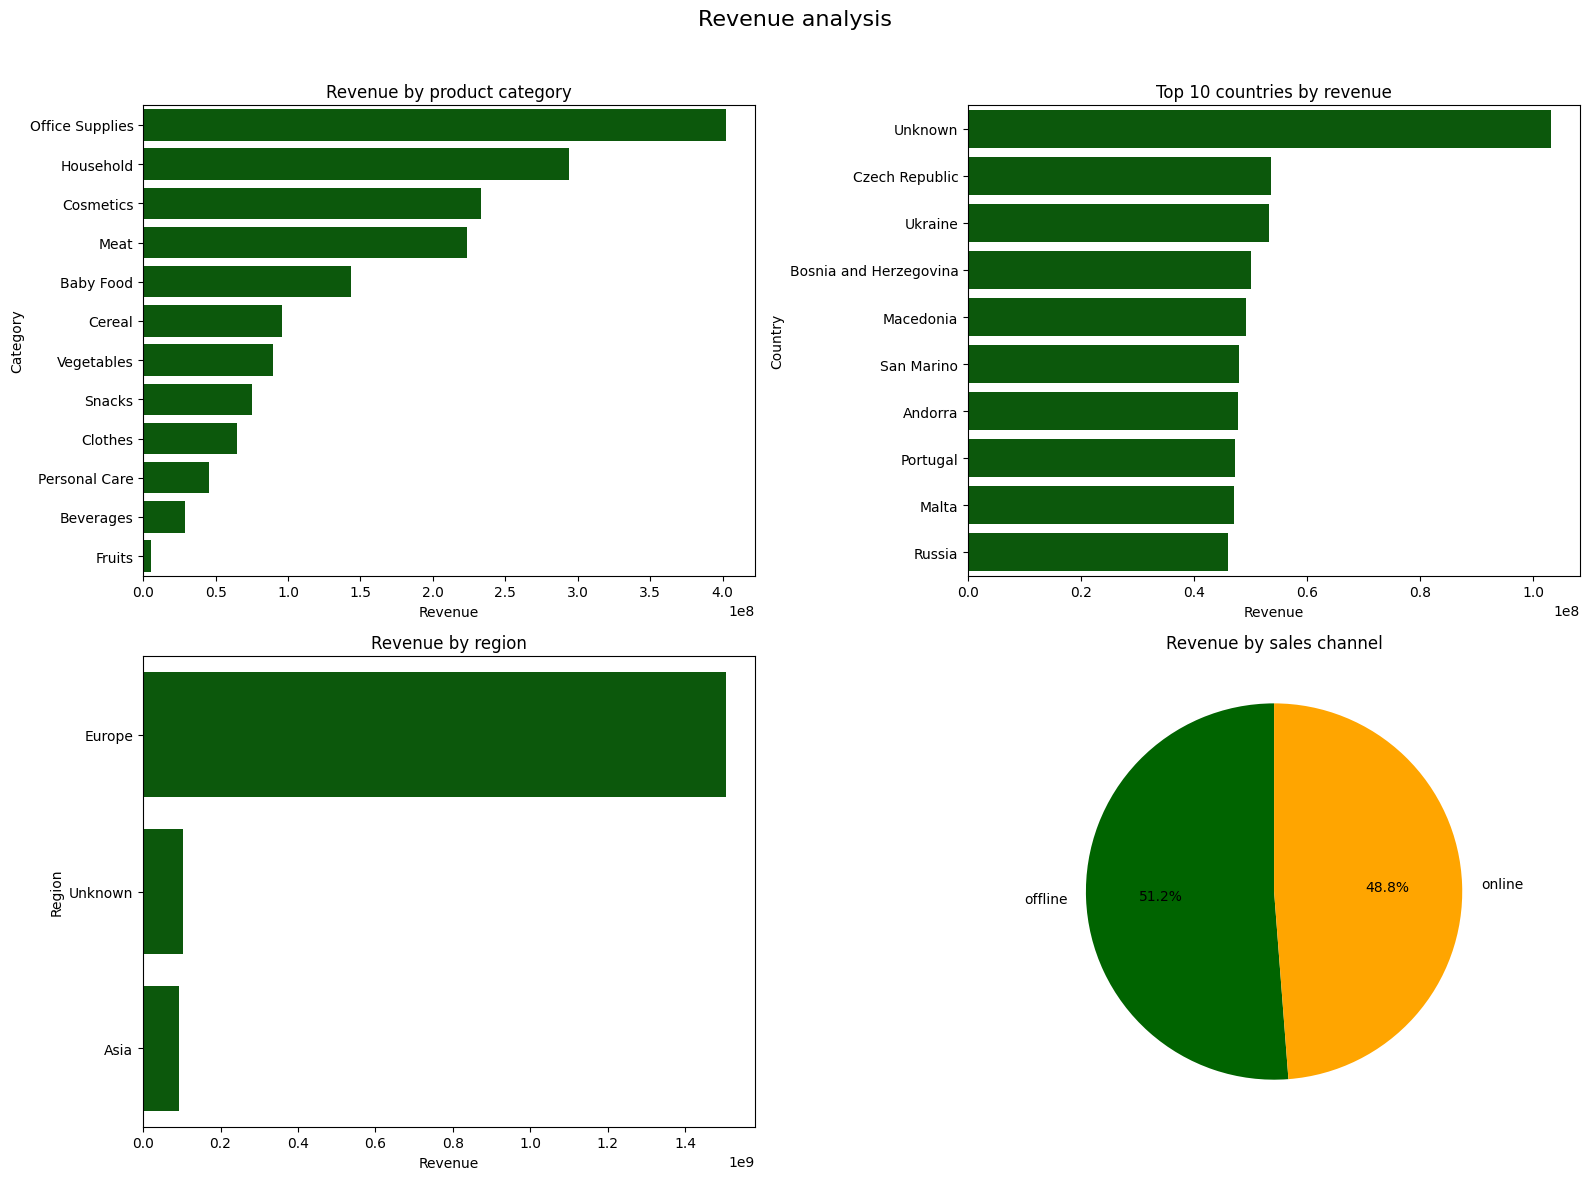

In [10]:
# Revenue visualization

import matplotlib.pyplot as plt
import seaborn as sns

revenue_by_category = df_merged.groupby("item_type")["Total Revenue"].sum().sort_values(ascending=False)
revenue_by_country = df_merged.groupby("name")["Total Revenue"].sum().sort_values(ascending=False).head(10)
revenue_by_region = df_merged.groupby("region")["Total Revenue"].sum().sort_values(ascending=False).head(10)
revenue_by_channel = df_merged.groupby("Sales Channel")["Total Revenue"].sum()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Revenue analysis", fontsize=16)

sns.barplot(ax=axes[0, 0], x=revenue_by_category.values, y=revenue_by_category.index, color="darkgreen")
axes[0, 0].set_title("Revenue by product category")
axes[0, 0].set_xlabel("Revenue")
axes[0, 0].set_ylabel("Category")

sns.barplot(ax=axes[0, 1], x=revenue_by_country.values, y=revenue_by_country.index, color="darkgreen")
axes[0, 1].set_title("Top 10 countries by revenue")
axes[0, 1].set_xlabel("Revenue")
axes[0, 1].set_ylabel("Country")

sns.barplot(ax=axes[1,0], x=revenue_by_region.values, y=revenue_by_region.index, color="darkgreen")
axes[1, 0].set_title("Revenue by region")
axes[1, 0].set_xlabel("Revenue")
axes[1, 0].set_ylabel("Region")

revenue_by_channel.plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', startangle=90, colors=['darkgreen', 'orange'])
axes[1, 1].set_title("Revenue by sales channel")
axes[1, 1].set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Conclusion
Based on the chart showing revenue by product category, we can conclude that the **Office Supplies** category generates the **highest revenue** (likely because there are many workplaces in offices where equipment needs to be replaced frequently), with a fairly significant lead over the other categories, while the **lowest** - **Fruits**. Accordingly, we can conclude that it is worth focusing on developing and scaling the Office Supplies category, while the Fruits category should be optimized or kept only as a supplementary option to attract customers.

According to the “Top 10 Countries by Revenue” chart, **the Czech Republic, Ukraine, and Bosnia and Herzegovina** **lead in revenue**.  This may indicate economic activity and efficient logistics in these countries.

By region, **Europe** leads by a wide margin, meaning this is the market we should continue to focus on.

According to the chart comparing **online** and **offline** sales channels, the difference in revenue is small, but **physical stores are still leading**. It makes sense to open more stores, but also to invest in developing online sales to expand into new countries and the **Asia** region.

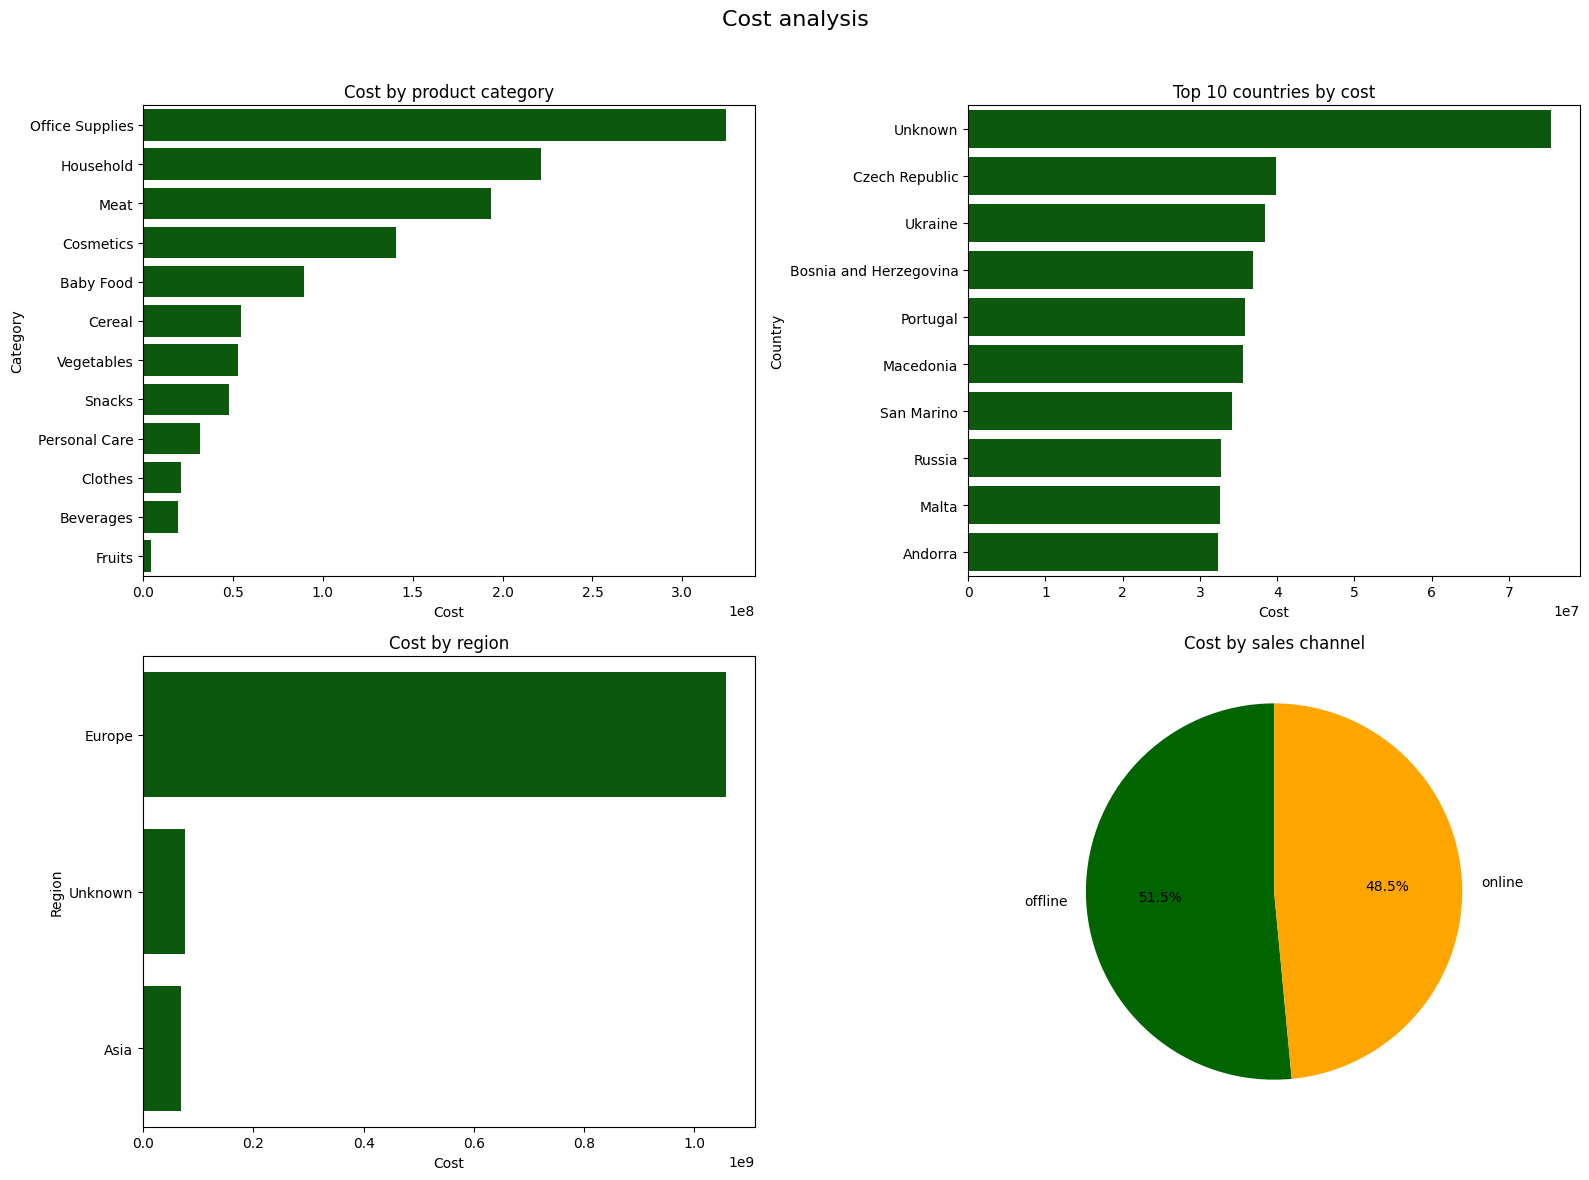

In [11]:
# Cost visualization

import matplotlib.pyplot as plt
import seaborn as sns

revenue_by_category = df_merged.groupby("item_type")["Total Cost"].sum().sort_values(ascending=False)
revenue_by_country = df_merged.groupby("name")["Total Cost"].sum().sort_values(ascending=False).head(10)
revenue_by_region = df_merged.groupby("region")["Total Cost"].sum().sort_values(ascending=False).head(10)
revenue_by_channel = df_merged.groupby("Sales Channel")["Total Cost"].sum()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Cost analysis", fontsize=16)

sns.barplot(ax=axes[0, 0], x=revenue_by_category.values, y=revenue_by_category.index, color="darkgreen")
axes[0, 0].set_title("Cost by product category")
axes[0, 0].set_xlabel("Cost")
axes[0, 0].set_ylabel("Category")

sns.barplot(ax=axes[0, 1], x=revenue_by_country.values, y=revenue_by_country.index, color="darkgreen")
axes[0, 1].set_title("Top 10 countries by cost")
axes[0, 1].set_xlabel("Cost")
axes[0, 1].set_ylabel("Country")

sns.barplot(ax=axes[1,0], x=revenue_by_region.values, y=revenue_by_region.index, color="darkgreen")
axes[1, 0].set_title("Cost by region")
axes[1, 0].set_xlabel("Cost")
axes[1, 0].set_ylabel("Region")

revenue_by_channel.plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', startangle=90, colors=['darkgreen', 'orange'])
axes[1, 1].set_title("Cost by sales channel")
axes[1, 1].set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Conclusion
After comparing the graphs with the analysis of income and expenses, it was concluded that the trend holds true: where there is more income, there are also higher expenses.

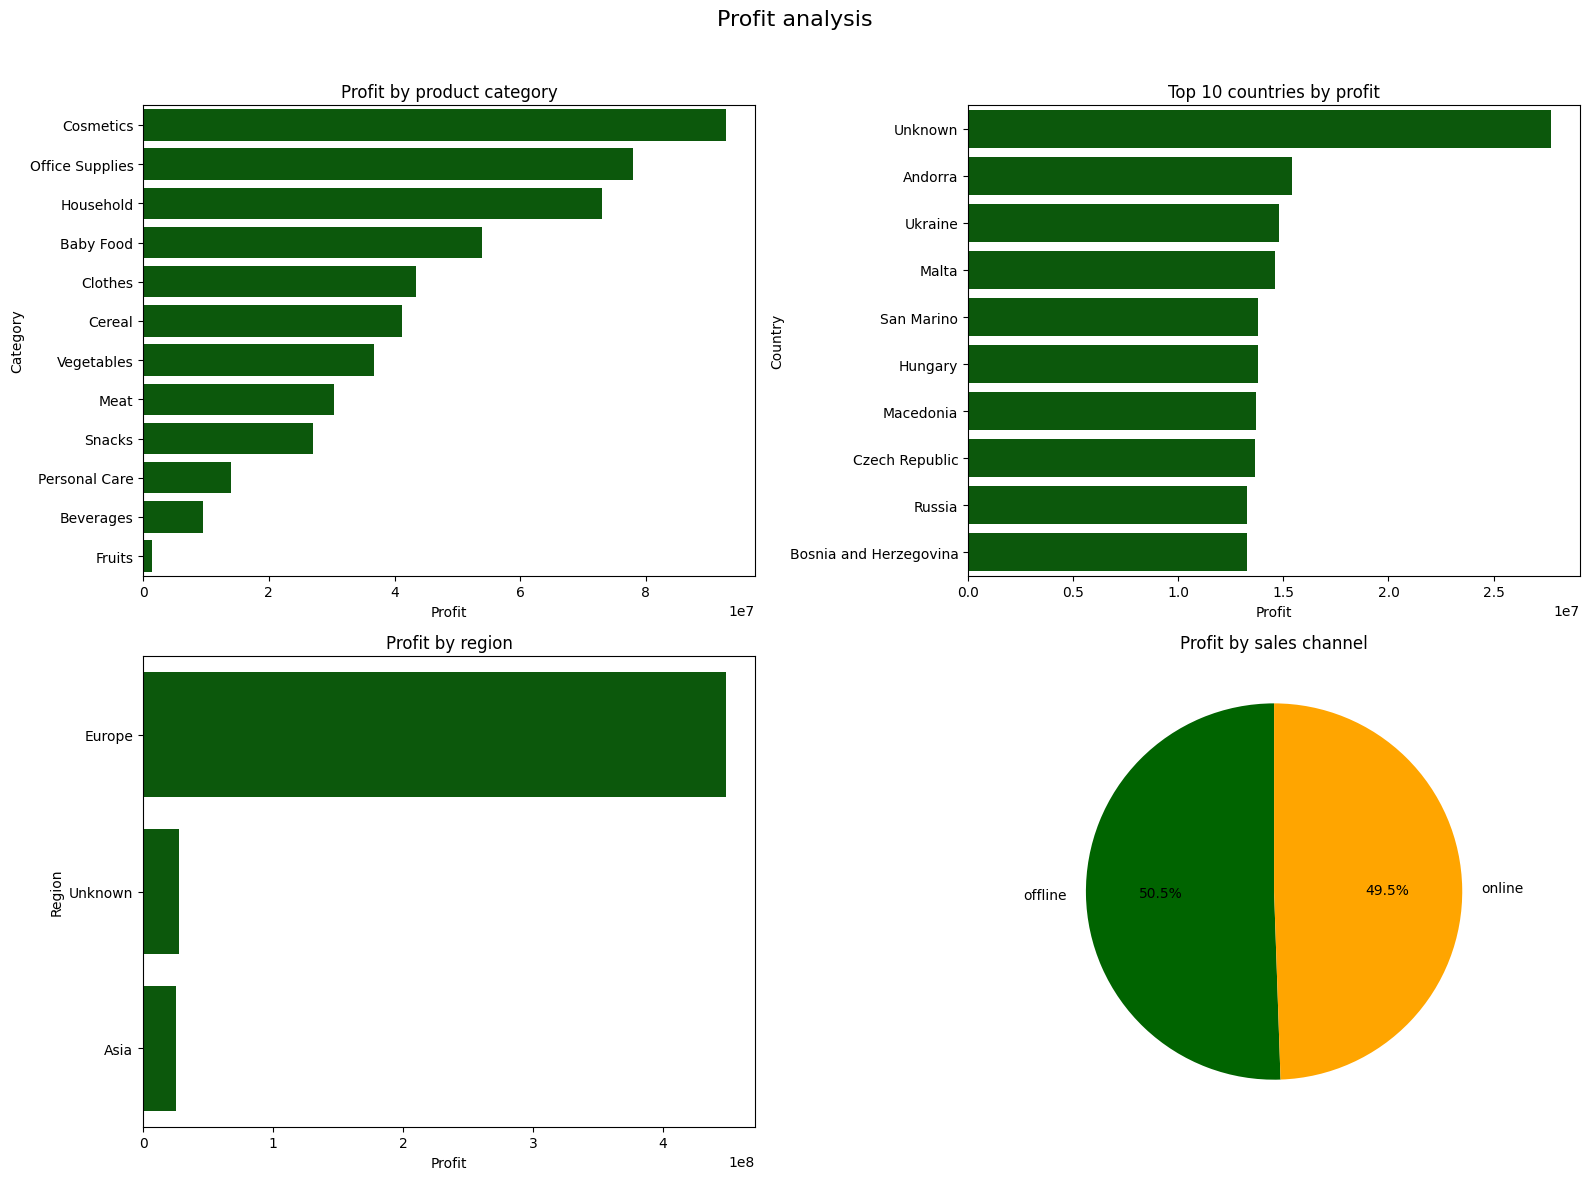

In [12]:
# Profit visualization

import matplotlib.pyplot as plt
import seaborn as sns

revenue_by_category = df_merged.groupby("item_type")["Profit"].sum().sort_values(ascending=False)
revenue_by_country = df_merged.groupby("name")["Profit"].sum().sort_values(ascending=False).head(10)
revenue_by_region = df_merged.groupby("region")["Profit"].sum().sort_values(ascending=False).head(10)
revenue_by_channel = df_merged.groupby("Sales Channel")["Profit"].sum()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Profit analysis", fontsize=16)

sns.barplot(ax=axes[0, 0], x=revenue_by_category.values, y=revenue_by_category.index, color="darkgreen")
axes[0, 0].set_title("Profit by product category")
axes[0, 0].set_xlabel("Profit")
axes[0, 0].set_ylabel("Category")

sns.barplot(ax=axes[0, 1], x=revenue_by_country.values, y=revenue_by_country.index, color="darkgreen")
axes[0, 1].set_title("Top 10 countries by profit")
axes[0, 1].set_xlabel("Profit")
axes[0, 1].set_ylabel("Country")

sns.barplot(ax=axes[1,0], x=revenue_by_region.values, y=revenue_by_region.index, color="darkgreen")
axes[1, 0].set_title("Profit by region")
axes[1, 0].set_xlabel("Profit")
axes[1, 0].set_ylabel("Region")

revenue_by_channel.plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', startangle=90, colors=['darkgreen', 'orange'])
axes[1, 1].set_title("Profit by sales channel")
axes[1, 1].set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Conclusion
An analysis of profits reveals an interesting trend: by category, the **Cosmetics** category generates the highest profit, indicating high profit margins and strong demand for this category.
**Office Supplies** and **Household** rank second and third, respectively, demonstrating the stable profitability of these segments. The least profitable categories are **Fruits**, **Beverages**, and **Personal Care**, which is likely due to lower prices or higher competition. Low-profit categories require analysis to identify the causes of their poor performance and assess the feasibility of their further development.

**Europe** is by far the most profitable region, so it makes sense to continue developing the business there.

**Online sales** and **offline sales** account for an almost equal share of profits. This indicates a balanced multichannel strategy.

In [13]:
# Analysis of the time interval between an order and its shipment, broken down by category
from IPython.display import display, Markdown
display(Markdown("**Analysis of the time interval between an order and its shipment, broken down by category**"))

longest_shipping_time = df_merged.groupby("item_type")["Time interval in days"].max()
fastest_shipping_time = df_merged.groupby("item_type")["Time interval in days"].min()
avg_shipping_time = round(df_merged.groupby("item_type")["Time interval in days"].mean().sort_values(ascending=False), 0)
avg_total_profit = round(df_merged.groupby("item_type")["Profit"].mean(), 2)

summary = pd.concat([longest_shipping_time, fastest_shipping_time, avg_shipping_time, avg_total_profit], axis=1)
summary.columns = ["Fastest shipping time", "Longest shipping time", "Average delay", "Average of Total Profit"]
print(summary.to_string(col_space=15, justify="center"))

**Analysis of the time interval between an order and its shipment, broken down by category**

                 Fastest shipping time  Longest shipping time   Average delay  Average of Total Profit
item_type                                                                                             
Baby Food                 50                      0                26.00             481,616.05       
Beverages                 50                      0                24.00              79,352.58       
Cereal                    50                      0                27.00             400,534.31       
Clothes                   50                      0                23.00             413,631.57       
Cosmetics                 50                      0                26.00             813,362.33       
Fruits                    50                      1                24.00              12,731.51       
Household                 50                      0                24.00             752,190.38       
Meat                      50                      0                26.00 

**Analysis of the time interval between an order and its shipment, broken down by country**

                        Fastest shipping time  Longest shipping time   Average delay  Average of Total Profit
name                                                                                                         
Albania                          49                      2                26.00             499,557.43       
Andorra                          50                      0                26.00             385,250.92       
Armenia                          50                      2                26.00             324,908.73       
Austria                          50                      3                28.00             358,125.34       
Belarus                          49                      1                25.00             423,300.75       
Belgium                          48                      1                27.00             287,540.77       
Bosnia and Herzegovina           50                      1                26.00             401,745.54       
Bulgaria  

**Analysis of the time interval between an order and its shipment, broken down by region**

                 Fastest shipping time  Longest shipping time   Average delay  Average of Total Profit
region                                                                                                
Asia                      50                      1                26.00             306,734.79       
Europe                    50                      0                25.00             384,697.07       
Unknown                   50                      0                23.00             338,114.93       


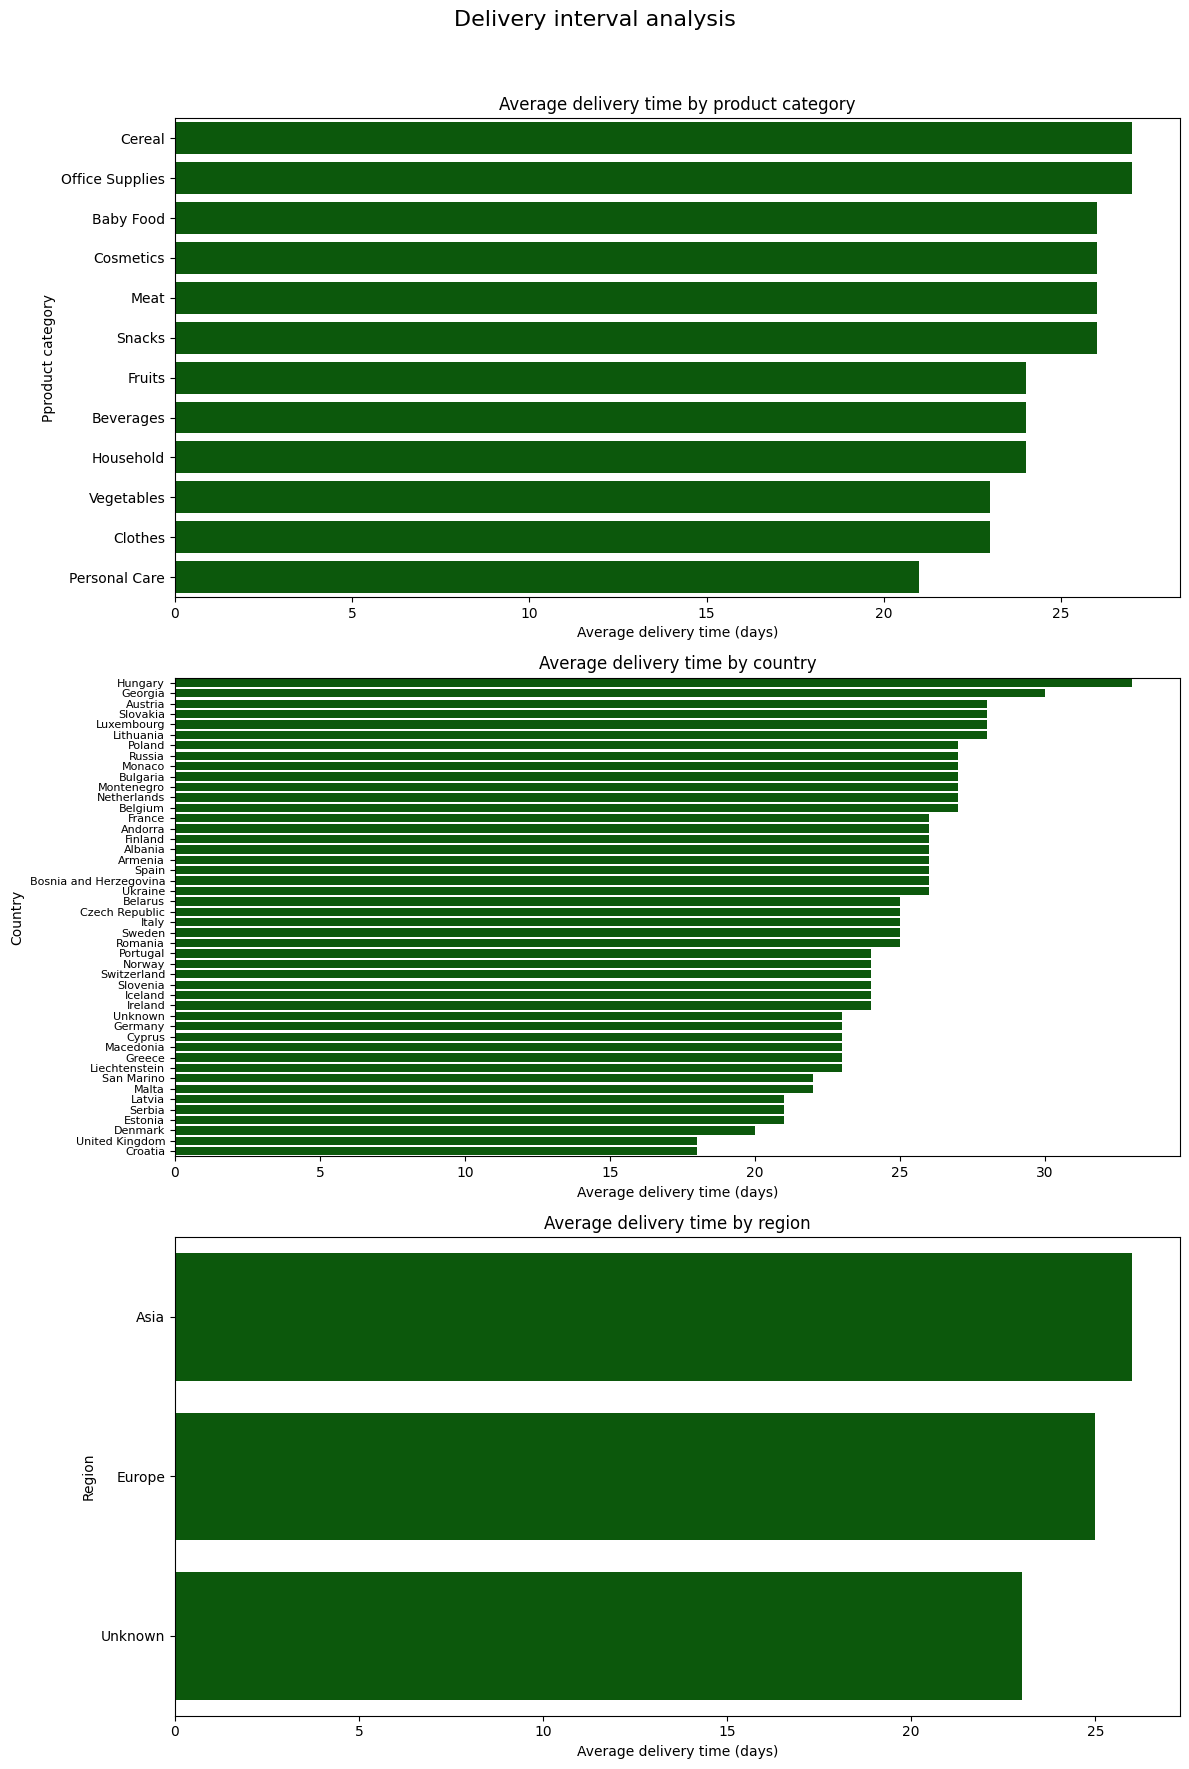

In [23]:
# Analysis of the time interval between an order and its shipment, broken down by country and region

pd.set_option("display.float_format", "{:,.2f}".format)

from IPython.display import display, Markdown
display(Markdown("**Analysis of the time interval between an order and its shipment, broken down by country**"))

longest_shipping_time_country = df_merged.groupby("name")["Time interval in days"].max()
fastest_shipping_time_country = df_merged.groupby("name")["Time interval in days"].min()
avg_shipping_time_country = round(df_merged.groupby("name")["Time interval in days"].mean().sort_values(ascending=False), 0)
avg_total_profit_country = round(df_merged.groupby("name")["Profit"].mean(), 2)

summary = pd.concat([longest_shipping_time_country, fastest_shipping_time_country, avg_shipping_time_country, avg_total_profit_country], axis=1)
summary.columns = ["Fastest shipping time", "Longest shipping time", "Average delay", "Average of Total Profit"]
print(summary.to_string(col_space=15, justify="center"))

print()
display(Markdown("**Analysis of the time interval between an order and its shipment, broken down by region**"))

longest_shipping_time_region = df_merged.groupby("region")["Time interval in days"].max()
fastest_shipping_time_region = df_merged.groupby("region")["Time interval in days"].min()
avg_shipping_time_region = round(df_merged.groupby("region")["Time interval in days"].mean().sort_values(ascending=False), 0)
avg_total_profit_region = round(df_merged.groupby("region")["Profit"].mean(), 2)

summary = pd.concat([longest_shipping_time_region, fastest_shipping_time_region, avg_shipping_time_region, avg_total_profit_region], axis=1)
summary.columns = ["Fastest shipping time", "Longest shipping time", "Average delay", "Average of Total Profit"]
print(summary.to_string(col_space=15, justify="center"))

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle("Delivery interval analysis", fontsize=16)

sns.barplot(
    ax=axes[0],
    x=avg_shipping_time.values,
    y=avg_shipping_time.index, color="darkgreen"
)
axes[0].set_title("Average delivery time by product category")
axes[0].set_xlabel("Average delivery time (days)")
axes[0].set_ylabel("Pproduct category")

sns.barplot(
    ax=axes[1],
    x=avg_shipping_time_country.values,
    y=avg_shipping_time_country.index, color="darkgreen"
)
axes[1].set_title("Average delivery time by country")
axes[1].set_xlabel("Average delivery time (days)")
axes[1].set_ylabel("Country")
axes[1].tick_params(axis="y", labelsize=8)

sns.barplot(
    ax=axes[2],
    x=avg_shipping_time_region.values,
    y=avg_shipping_time_region.index, color="darkgreen"
)
axes[2].set_title("Average delivery time by region")
axes[2].set_xlabel("Average delivery time (days)")
axes[2].set_ylabel("Region")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Conclusion
The longest average processing time is observed for items in the **Cereal** category — about 25 days. Products in the **Office Supplies**, **Baby Food**, and **Cosmetics** categories also have relatively long processing times — 23–24 days. Orders in the **Personal Care** category are processed the fastest (approximately 20 days). In most categories, processing times range from 21 to 24 days.

Orders in **Hungary** and **Georgia** take the longest to process — on average about 30 days — while those in **Croatia** and the **United Kingdom** are processed the fastest (approximately 20 days). Most European countries have a processing time of 22–28 days, with differences between countries reaching up to 10 days.

Order processing times in **Asia** and **Europe** are virtually the same — about 25 days.

Thus, the product category has a greater impact on processing time than the delivery region. Minor regional differences indicate standardized processing procedures at the regional level.

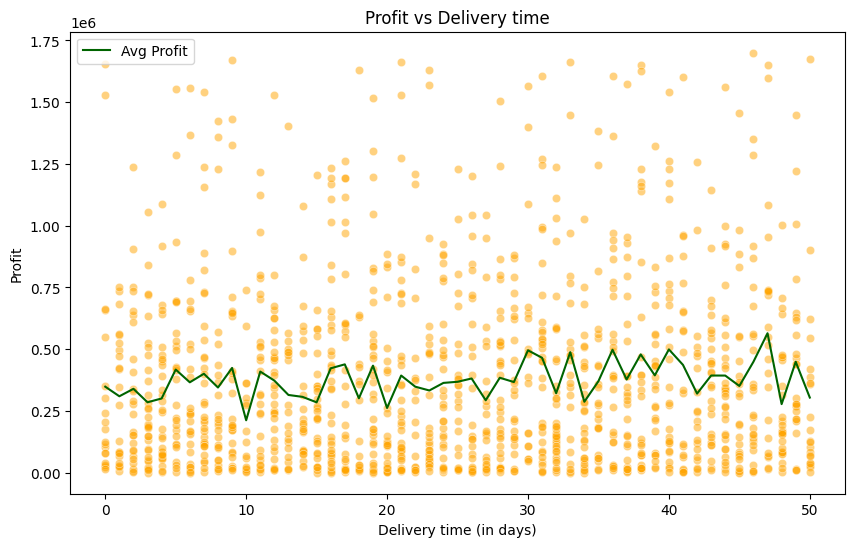

In [24]:
# Analysis of the relationship between profit and delivery time
avg_profit_by_shipping = df_merged.groupby("Time interval in days")["Profit"].mean()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_merged, x="Time interval in days", y="Profit", alpha=0.5, color='orange')
sns.lineplot(x=avg_profit_by_shipping.index, y=avg_profit_by_shipping.values, color='darkgreen', label='Avg Profit')
plt.xlabel('Delivery time (in days)')
plt.ylabel('Profit')
plt.title('Profit vs Delivery time')
plt.legend()
plt.show()

# Conclusion
The graph shows that there is no clear correlation between profit and delivery time.
Average profit fluctuates but does not show a clear trend of increasing or decreasing with delivery time.

There is also significant variation in the data. For any given delivery time, there are both highly profitable and low-profit orders — meaning that profit does not depend heavily on delivery speed.

Delivery delays do not have a significant impact on profit. It is likely that other factors (product type, region, customer, etc.) have a greater influence on profit.

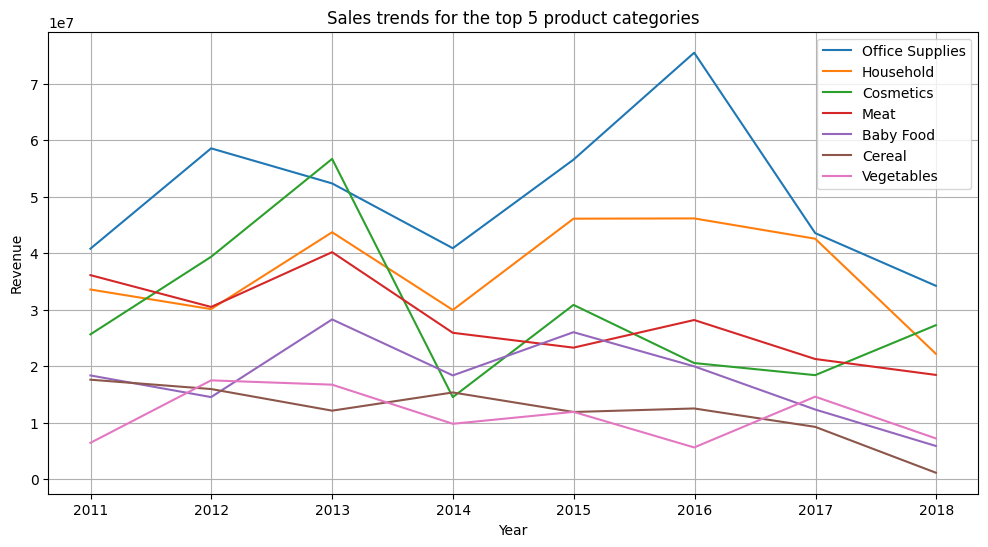

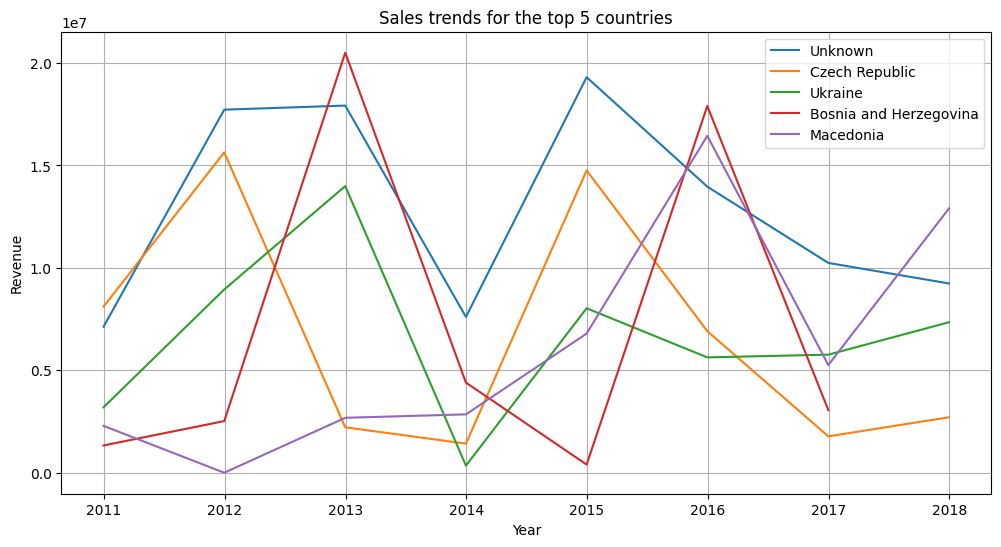

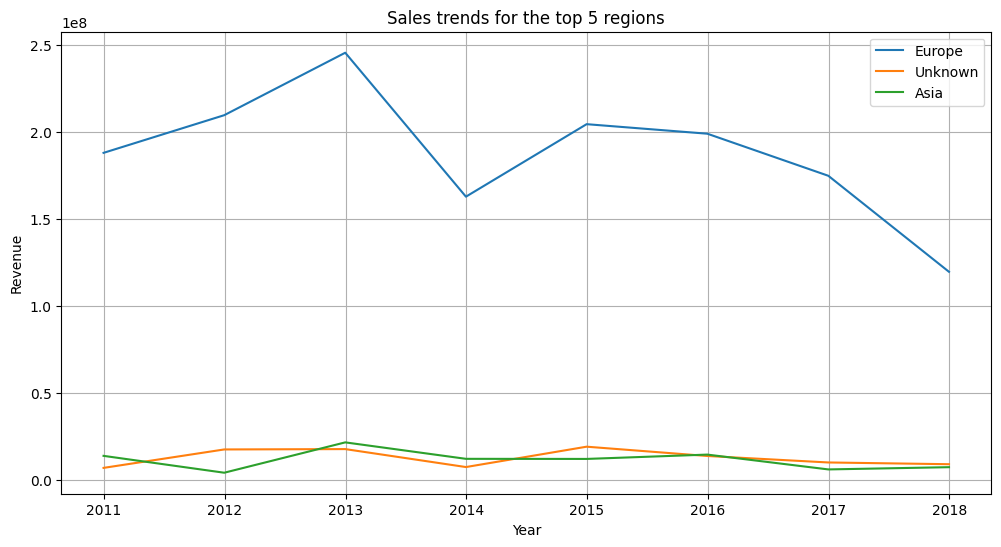

In [25]:
# Analysis of sales trends (over time) by product category, country, and region

# Identification of the top 5 categories, countries, and regions by total revenue
top_categories = df_merged.groupby('item_type')['Total Revenue'].sum().nlargest(7).index
top_countries = df_merged.groupby('name')['Total Revenue'].sum().nlargest(5).index
top_regions = df_merged.groupby('region')['Total Revenue'].sum().nlargest(5).index

# Filtering data for the top 5
filtered_categories = df_merged[df_merged['item_type'].isin(top_categories)]
filtered_countries = df_merged[df_merged['name'].isin(top_countries)]
filtered_regions = df_merged[df_merged['region'].isin(top_regions)]

# Sales trends by category
time_series_category = (
    filtered_categories.set_index('Order Date')
    .groupby('item_type')['Total Revenue']
    .resample('YE')
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
for category in top_categories:
    category_data = time_series_category[time_series_category['item_type'] == category]
    plt.plot(category_data['Order Date'], category_data['Total Revenue'], label=category)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Sales trends for the top 5 product categories")
plt.legend()
plt.grid(True)
plt.show()

# Sales trends by country
time_series_country = (
    filtered_countries.set_index('Order Date')
    .groupby('name')['Total Revenue']
    .resample('YE')
    .sum()
    .reset_index()
)

print()
plt.figure(figsize=(12, 6))
for country in top_countries:
    country_data = time_series_country[time_series_country['name'] == country]
    plt.plot(country_data['Order Date'], country_data['Total Revenue'], label=country)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Sales trends for the top 5 countries")
plt.legend()
plt.grid(True)
plt.show()

# Sales trends by region
time_series_region = (
    filtered_regions.set_index('Order Date')
    .groupby('region')['Total Revenue']
    .resample('YE')
    .sum()
    .reset_index()
)

print()
plt.figure(figsize=(12, 6))
for region in top_regions:
    region_data = time_series_region[time_series_region['region'] == region]
    plt.plot(region_data['Order Date'], region_data['Total Revenue'], label=region)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Sales trends for the top 5 regions")
plt.legend()
plt.grid(True)
plt.show()

#Conclusion
The **Office Supplies** category is the undisputed sales leader, peaking in 2016. **Household** consistently holds second place. **Cosmetics** shows significant fluctuations: a sharp increase in 2013 followed by a decline.
**Meat** remains relatively stable, though with a slight decline. **Baby Food**, **Cereal**, and **Vegetables** have the lowest sales, which have been gradually decreasing since 2017.

Among countries, peak fluctuations are observed in all countries.

**Europe significantly outpaces Asia** in terms of sales volume. In Europe, the trend is clear: growth through 2013, a decline in 2014, a recovery in 2015, and a gradual decline through 2018. Asia has consistently low figures with no significant changes.

/tmp/ipykernel_1106/80232605.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


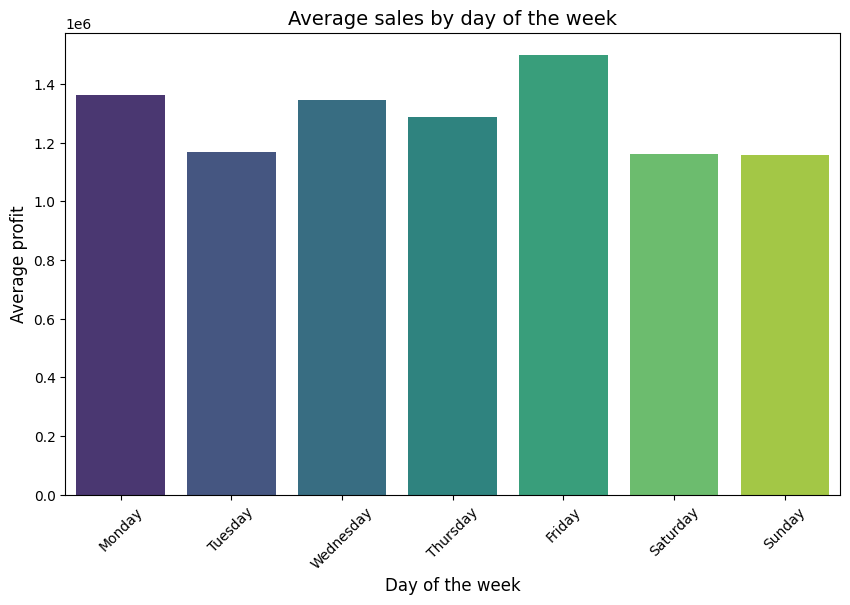

In [26]:
df_merged['Weekday'] = df_merged['Order Date'].dt.day_name()

sales_by_weekday = df_merged.groupby('Weekday')['Total Revenue'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(10, 6))
sns.barplot(
    x=sales_by_weekday.index,
    y=sales_by_weekday.values,
    palette='viridis'
)
plt.title('Average sales by day of the week', fontsize=14)
plt.xlabel('Day of the week', fontsize=12)
plt.ylabel('Average profit', fontsize=12)
plt.xticks(rotation=45)
plt.show()


# Conclusion
It is clear that sales figures are higher on weekdays. The sales peak on Friday may be due to increased buyer activity, as shopping may be seen as a form of relaxation after the workweek. The decline on weekends is to be expected, since most business transactions take place on weekdays.